# Does Tokyo move the market on cue? 🇯🇵🏦
### The BoJ Announcement Effect — a plausible-sounding legend that turns out to be **mostly noise**, with one loud exception

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bigger_swings%3F: Confirmed](https://img.shields.io/badge/Bigger_swings%3F-Confirmed-8b949e?style=flat-square)

Eight (sometimes more) times a year, the Bank of Japan's Policy Board announces what it will do with interest rates and its bond-buying program. Everyone remembers a handful of these days — the shock negative-rate cut in 2016, the 2022 "Kuroda shock" that sent the yen flying, the 2024 hike that helped trigger a global market wobble. Surely, the story goes, **BoJ day is a systematically bigger day** for Japanese stocks and the yen?

We tested it on 247 BoJ decisions since 2005. The honest answer has two very different halves.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 248 hardcoded BoJ decision dates (2005→2026) from the Bank of Japan's own archives — every decision on record, since this claim is explicitly about the surprise-driven eras. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from boj_announcement_effect import data, strategy as st

BOJ = data.boj_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    EWJ, JPY = data.load_real()
    DF = st.day_frame(EWJ, JPY, BOJ)
else:
    EWJ = JPY = DF = None
print("real cache present:", HAVE_REAL, "| BoJ decisions:", len(BOJ),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_boj': 247, 'n_rest': 5157, 'n_hardcoded': 248, 'cal_lo': '2005-01-19', 'cal_hi': '2026-06-16', 'ewj_boj': 0.008, 'ewj_rest': 0.0145, 'ewj_gap': -0.0065, 'ewj_t': -0.06, 'ewj_nw': -0.06, 'ewj_hit': 118, 'ewj_hit_pct': 47.8, 'ewj_wilson': (41.6, 54.0), 'jpy_boj': -0.0633, 'jpy_rest': -0.0058, 'jpy_gap': -0.0575, 'jpy_t': -0.85, 'jpy_nw': -0.85, 'jpy_hit': 117, 'jpy_hit_pct': 47.4, 'jpy_wilson': (41.2, 53.6), 'ewj_placebo_p': 0.9223, 'ewj_placebo_mean': 0.0147, 'ewj_placebo_sd': 0.0788, 'jpy_placebo_p': 0.1584, 'jpy_placebo_mean': -0.0057, 'jpy_placebo_sd': 0.0453, 'placebo_draws': 20000, 'event': {-5: (-0.127, -1.76, 0.026, 0.52), -4: (-0.072, -1.4, 0.036, 0.68), -3: (0.016, -0.19, -0.058, -1.19), -2: (-0.104, -1.51, -0.051, -1.02), -1: (0.105, 0.69, 0.007, 0.21), 0: (0.04, 0.04, -0.042, -0.65), 1: (0.013, -0.23, 0.036, 0.98), 2: (-0.011, -0.49, -0.026, -0.51), 3: (-0.004, -0.49, -0.077, -0.88)}, 'ewj_range_boj': 1.164, 'ewj_range_rest': 0.995, 'ewj_range_t': 2.49, 'jpy_range_boj': 1.059, 'jpy_range_rest': 0.76, 'jpy_range_t': 6.3, 'era_split': '2016-01-29', 'ewj_early': -0.001, 'ewj_early_n': 162, 'ewj_early_t': -0.02, 'ewj_late': 0.025, 'ewj_late_n': 85, 'ewj_late_t': -0.02, 'ewj_diff_t': 0.13, 'jpy_early': -0.1, 'jpy_early_n': 162, 'jpy_early_t': -1.19, 'jpy_late': 0.006, 'jpy_late_n': 85, 'jpy_late_t': 0.16, 'jpy_diff_t': 0.75, 'tail': {'2016-01-29': ('NIRP announced', 2.38, 1.41, -2.01, -1.86, 1.87, 2.64), '2016-09-21': ('YCC introduced', 2.88, 1.71, 1.18, 1.19, 1.14, 2.18), '2022-12-20': ('YCC band widened ("Kuroda shock")', 1.41, 0.84, 3.8, 3.69, 1.29, 4.7), '2023-07-28': ('YCC made more flexible', 0.57, 0.33, -1.35, -1.23, 0.62, 2.06), '2023-10-31': ('YCC further loosened', 1.21, 0.72, -1.45, -1.33, 0.84, 1.68), '2024-03-19': ('NIRP/YCC formally ended', 0.38, 0.22, -1.26, -1.14, 0.79, 1.15), '2024-07-31': ('Rate hike to ~0.25%', 2.9, 1.72, 1.94, 1.91, 0.99, 2.57)}, 'ewj_gross': 0.8, 'ewj_net5': -9.2, 'ewj_net10': -19.2, 'ewj_worst': -8.06, 'ewj_best': 5.97, 'jpy_gross': -6.33, 'jpy_net5': -16.33, 'jpy_net10': -26.33, 'jpy_worst': -7.8, 'jpy_best': 3.8, 'syn_null_mean': -0.23, 'syn_null_sd': 1.34, 'syn_null_fire': 3, 'syn_null_seeds': 20, 'syn_100seed_fp': 3, 'syn_planted_effect': 0.2, 'syn_planted_t': 5.46, 'fp_ewj': 'e6d94e03a855', 'fp_jpy': '70f450fc971e'}


real cache present: True | BoJ decisions: 248 | tape days: 5404


## The answer first

| Question | Answer |
|---|---|
| Do Japanese stocks (EWJ) move predictably on BoJ days? | **No.** **+0.008%** on the average decision day vs +0.015% normally — statistically indistinguishable from zero, and stocks were UP on only **48%** of decisions (below a coin flip). |
| Does the yen move predictably on BoJ days? | **No, either.** **-0.063%** vs -0.006% normally — also statistically nothing. |
| Is the "surprise era" (NIRP/YCC, 2016 onward) any different? | **Not on average.** Same coin-flip pattern before and after the negative-rate shock. |
| Are BoJ days actually calmer or louder than normal? | **Louder — genuinely.** Both instruments swing more that day than an average day. The catch: which *direction* they swing is unpredictable. |

> The BoJ can move markets hugely on any given day. It just can't tell you which way — and neither, on average, can the calendar.

## 1 · The claim

> *"The Bank of Japan is the last major central bank still capable of shocking the market — negative rates, yield-curve control, the world's biggest bond-buying program. When it moves, Japanese stocks and the yen move with it."*

It's a reasonable prior: the BoJ has delivered several of the biggest single-day FX moves of the past decade, and unlike the Fed (which telegraphs its reaction function months ahead), a large share of BoJ decisions genuinely surprised the market. The question is whether that surprise-power shows up as a *systematic*, tradable pattern — or only as a handful of unforgettable outliers.

## 2 · So what?

If BoJ days really moved markets systematically, that would be a clean, calendar-based edge: you'd know the date years in advance, position ahead of it, and collect a repeatable premium. If instead the reaction is all in a handful of huge, sign-flipping surprises, there's nothing to harvest on an *average* decision day — just tail risk to respect on the rare one that matters.

## 3 · How would we even know?

- **The calendar.** All **248** BoJ decision/statement dates from 2005-01-19 to 2026-06-16, hardcoded from the Bank of Japan's own archives — every decision, scheduled or emergency, because this claim is about the surprise eras specifically.
- **The comparison.** EWJ (Japan equities, USD) and the yen's return on those **247** days vs the other **5,157** trading days since 2005.
- **The luck check.** Draw 247 random days instead, 20,000 times, two-sided (a BoJ surprise can go either way) — how often does a random calendar produce a gap this large?
- **The amplitude check.** Regardless of direction — is the *swing* (high-low range) actually bigger on decision days?

## 4 · The teardown — let's actually look

**First, the headline.** Average daily return on BoJ decision days vs every other day, for both instruments.

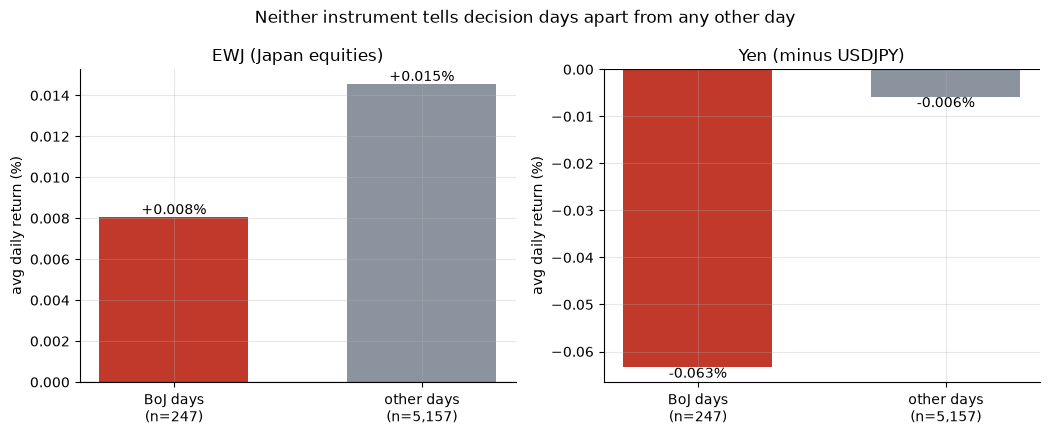

EWJ +0.0080% vs +0.0145%   yen -0.0633% vs -0.0058%


In [2]:
if HAVE_REAL:
    se = st.decision_day_stats(DF, 'ewj_ret'); sj = st.decision_day_stats(DF, 'jpy_ret')
    ea, eb, ja, jb = se['boj_pct'], se['rest_pct'], sj['boj_pct'], sj['rest_pct']
else:
    ea, eb, ja, jb = R['ewj_boj'], R['ewj_rest'], R['jpy_boj'], R['jpy_rest']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar(['BoJ days\n(n=247)','other days\n(n=5,157)'], [ea, eb], color=[RED, GREY], width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('avg daily return (%)'); a1.set_title('EWJ (Japan equities)')
for i,v in enumerate([ea, eb]): a1.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.bar(['BoJ days\n(n=247)','other days\n(n=5,157)'], [ja, jb], color=[RED, GREY], width=.6)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('avg daily return (%)'); a2.set_title('Yen (minus USDJPY)')
for i,v in enumerate([ja, jb]): a2.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.suptitle('Neither instrument tells decision days apart from any other day')
plt.tight_layout(); plt.show()
print(f'EWJ {ea:+.4f}% vs {eb:+.4f}%   yen {ja:+.4f}% vs {jb:+.4f}%')

The bars are nearly indistinguishable. EWJ hit rate: only **48%** of decisions were up days (below a coin flip). Yen hit rate: **47%**. The quants notebook shows a random calendar reproduces both gaps the large majority of the time — this is not a fluke of small samples, it's a genuine null.

**But here's the twist.** Even though the *direction* is a wash, is the *size* of the move on those days bigger?

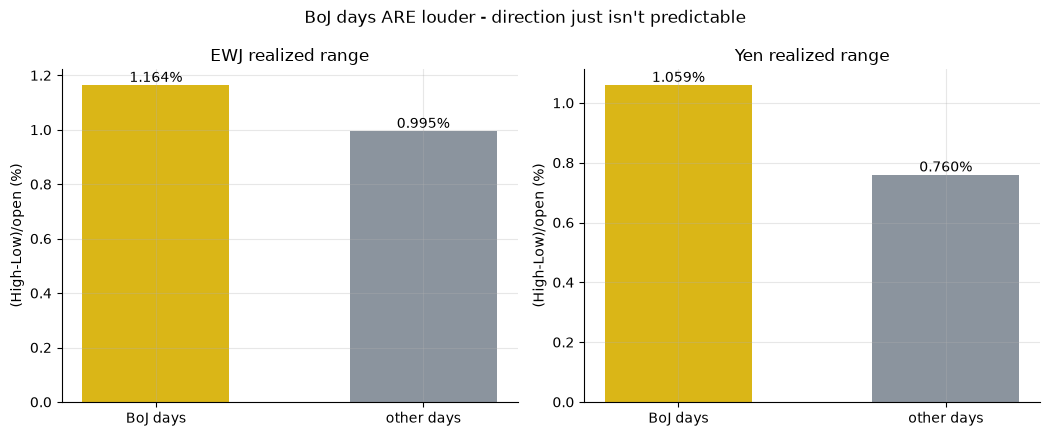

EWJ range 1.164% vs 0.995%   yen range 1.059% vs 0.760%


In [3]:
if HAVE_REAL:
    rge = st.range_stats(DF, 'ewj_range'); rgj = st.range_stats(DF, 'jpy_range')
    ea2, eb2, ja2, jb2 = rge['boj_pct'], rge['rest_pct'], rgj['boj_pct'], rgj['rest_pct']
else:
    ea2, eb2 = R['ewj_range_boj'], R['ewj_range_rest']
    ja2, jb2 = R['jpy_range_boj'], R['jpy_range_rest']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar(['BoJ days','other days'], [ea2, eb2], color=[AMBER, GREY], width=.55)
a1.set_title('EWJ realized range'); a1.set_ylabel('(High-Low)/open (%)')
for i,v in enumerate([ea2, eb2]): a1.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
a2.bar(['BoJ days','other days'], [ja2, jb2], color=[AMBER, GREY], width=.55)
a2.set_title('Yen realized range'); a2.set_ylabel('(High-Low)/open (%)')
for i,v in enumerate([ja2, jb2]): a2.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
plt.suptitle('BoJ days ARE louder - direction just isn\'t predictable')
plt.tight_layout(); plt.show()
print(f'EWJ range {ea2:.3f}% vs {eb2:.3f}%   yen range {ja2:.3f}% vs {jb2:.3f}%')

Both instruments swing meaningfully more on decision days. That's the real, certified finding of this study: **BoJ days are louder** — the folklore has a true kernel, it's just about *volatility*, not *direction*.

**So where does the folklore come from?** From a handful of genuinely huge, unforgettable days.

C:\Users\loutr\AppData\Local\Temp\ipykernel_17072\1028578308.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels, rotation=30, ha='right')


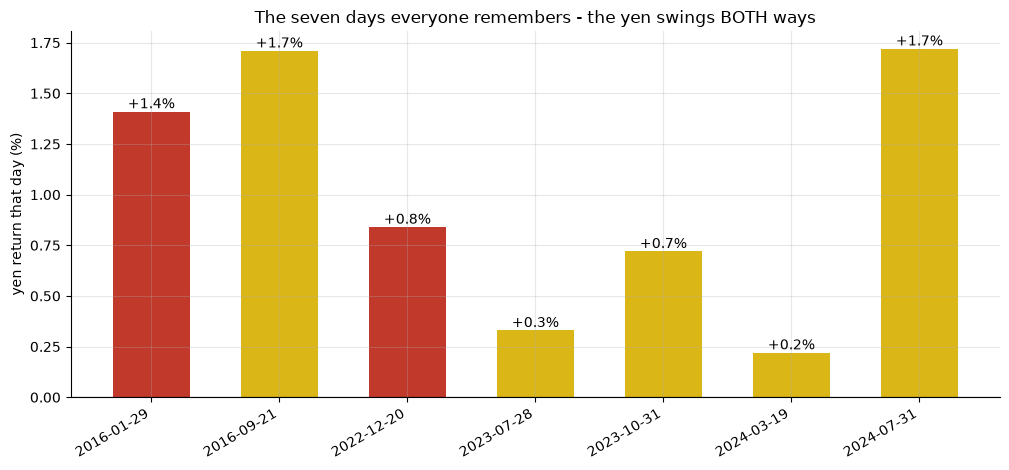

{'2016-01-29': 'NIRP announced', '2016-09-21': 'YCC introduced', '2022-12-20': 'YCC band widened ("Kuroda shock")', '2023-07-28': 'YCC made more flexible', '2023-10-31': 'YCC further loosened', '2024-03-19': 'NIRP/YCC formally ended', '2024-07-31': 'Rate hike to ~0.25%'}


In [4]:
labels = list(R['tail'].keys())
jvals = [R['tail'][d][3] for d in labels]
cols = [RED if abs(v) >= 2 else AMBER for v in jvals]
fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.bar(labels, [R['tail'][d][2] for d in labels], color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('yen return that day (%)')
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title('The seven days everyone remembers - the yen swings BOTH ways')
for i, d in enumerate(labels):
    v = R['tail'][d][2]
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print({d: R['tail'][d][0] for d in labels})

Notice the yen moves in **both** directions across these seven famous surprises — weakening on the dovish NIRP/YCC-loosening days, strengthening sharply on the hawkish band-widening/hike days. Japanese stocks (EWJ), meanwhile, went **up on every single one** — a relief-rally pattern that has nothing to do with whether the surprise was hawkish or dovish. Only one day (the December-2022 "Kuroda shock") individually clears our statistical bar on any metric: the yen jumped **+3.8%** in a single session. That's a real, occasionally enormous tail event — not a repeatable calendar pattern.

**Finally, the trade.** Even ignoring statistics for a moment — is there anything left to harvest, net of costs?

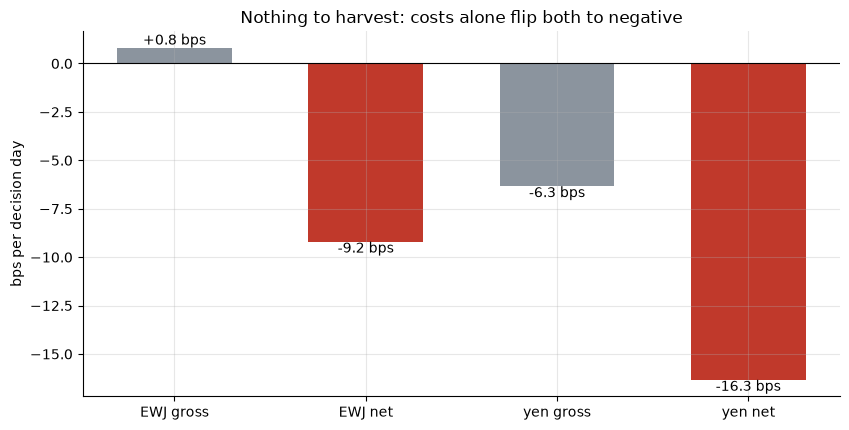

EWJ gross +0.8 -> net -9.2 bps   yen gross -6.3 -> net -16.3 bps


In [5]:
if HAVE_REAL:
    ce = st.decision_day_capture(DF, 'ewj_ret', cost_bps=5.0)
    cj = st.decision_day_capture(DF, 'jpy_ret', cost_bps=5.0)
    ge, ne, gj, nj = ce['gross_bps'], ce['net_bps'], cj['gross_bps'], cj['net_bps']
else:
    ge, ne, gj, nj = R['ewj_gross'], R['ewj_net5'], R['jpy_gross'], R['jpy_net5']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['EWJ gross','EWJ net','yen gross','yen net'], [ge, ne, gj, nj],
       color=[GREY, RED, GREY, RED], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([ge, ne, gj, nj]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.set_ylabel('bps per decision day')
ax.set_title('Nothing to harvest: costs alone flip both to negative')
plt.tight_layout(); plt.show()
print(f'EWJ gross {ge:+.1f} -> net {ne:+.1f} bps   yen gross {gj:+.1f} -> net {nj:+.1f} bps')

Gross is already close to zero on both legs. Add costs and both flip decisively negative. There's no "buy the dip before BoJ day" edge in this data — just volatility risk you should size for, not a return you should chase.

## 5 · The verdict

- **Signal — None.** No systematic directional reaction in EWJ or the yen across 247 BoJ decisions since 2005, in or out of the NIRP/YCC surprise era.
- **Tradability — Mirage.** With no average edge, costs alone make both legs losers.
- **"BoJ days swing more than average"? — Confirmed.** They genuinely do — the folklore's kernel of truth is about *amplitude*, carried by a handful of huge, sign-flipping tail events, not a repeatable *direction*.

## 6 · Going further 🚪

- **The general lesson.** "A scheduled announcement moves the market" and "a scheduled announcement moves the market *in a knowable direction*" are two very different claims — this study busts the second while confirming the first.
- **Where the real risk sits** is the tail, not the average: an investor holding unhedged Japan exposure through a BoJ meeting should size for an occasional multi-percent single-day move, not expect a systematic drift.
- **Sibling studies:** [615-yen-safe-haven](../../615-yen-safe-haven/) (the yen's general risk-off reaction, any day) and [637-fomc-vol-crush](../../637-fomc-vol-crush/) (the Fed's decision-day effect on implied vol) ask related but different questions about scheduled central-bank days.

*Think the surprise era is different? Show a directionally-predictive signal, certified at t ≥ 2, that survives the full NIRP/YCC sample — then we'll talk.*